In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import os
from pathlib import Path
import io
from Scheduler import DDPM
import matplotlib.pyplot as plt

from torchvision import transforms


In [133]:
class dataset_imgs(Dataset):
    def __init__(self, folder: str,
                 betas_start: float = 1e-4,
                 betas_end: float = 1e-2,
                 max_timesteps: int = 1000):

        self.folder = Path(folder)
        allowed_exts = {".png", ".jpg", ".jpeg"}

        self.all_pths = [
            self.folder / name
            for name in os.listdir(self.folder)
            if Path(name).suffix.lower() in allowed_exts
        ]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((256, 256)),
        ])

        self.ddpm = DDPM(betas_start, betas_end, max_timesteps)

        # valid DDPM timesteps are 0..999
        self.ts = torch.arange(max_timesteps, dtype=torch.long)

    def __len__(self):
        return len(self.all_pths)

    def __getitem__(self, index):
        selected = self.all_pths[index]

        img = plt.imread(selected)

        number = float(selected.stem)

        img = self.transform(img)

        t = self.ts[torch.randint(0, len(self.ts), (1,))].item()

        x_t, noise = self.ddpm.add_noise(
            img.unsqueeze(0),
            torch.tensor([t], dtype=torch.long)
        )

        x_t = x_t.squeeze(0)
        noise = noise.squeeze(0)

        return img, x_t, noise, t, number

In [46]:
str(Path("wow/hi"))

'wow/hi'

In [144]:
dataset = dataset_imgs("Temp Dataset")
dataloader  = DataLoader(dataset, batch_size = 5, shuffle = True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6998901..2.7687316].


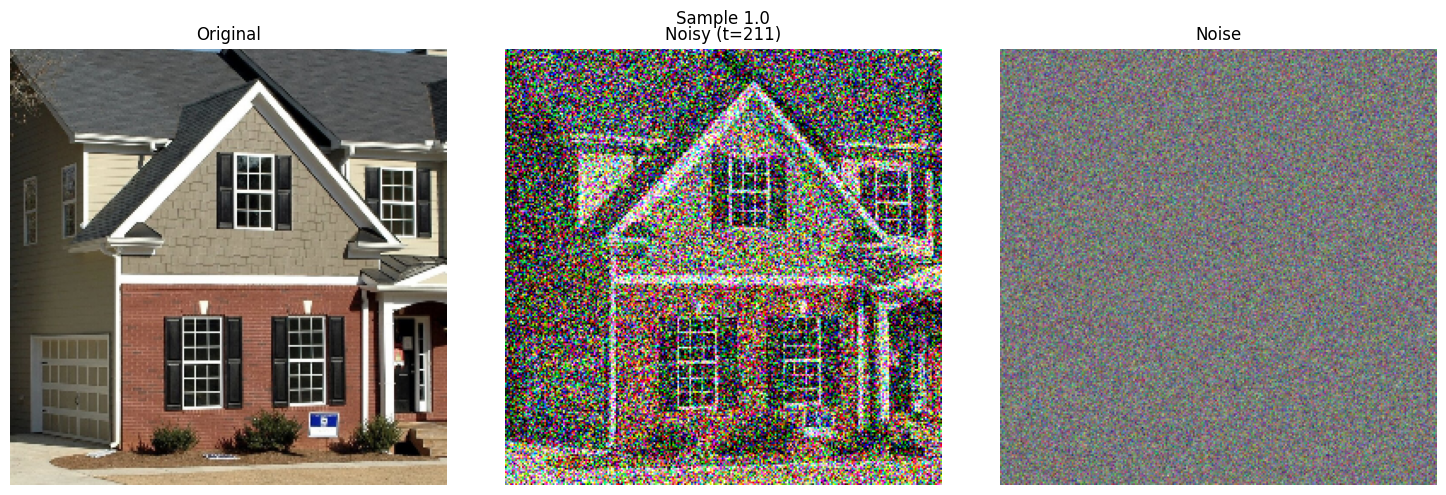

In [148]:
sample = next(iter(dataloader))

img       = sample[0][0].permute(1, 2, 0).cpu().numpy()
noisy_img = sample[1][0].permute(1, 2, 0).cpu().numpy()
noise     = sample[2][0].permute(1, 2, 0).cpu().numpy()

t = sample[3][0].item()
number = sample[4][0].item()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(noisy_img)
ax[1].set_title(f"Noisy (t={t})")
ax[1].axis("off")

# visualize noise
noise_vis = (noise - noise.min()) / (noise.max() - noise.min())
ax[2].imshow(noise_vis)
ax[2].set_title("Noise")
ax[2].axis("off")

plt.suptitle(f"Sample {number}")
plt.tight_layout()
plt.show()

In [119]:
noisy_img.shape

(256, 256, 3)

In [105]:
plt.imshow(next(iter(dataloader))[0].permute(1,2,0).detach().cpu().numpy())

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

In [111]:
next(iter(dataloader))[0][0].permute(1,2,0).detach().cpu().numpy()

array([[[0.63529414, 0.59607846, 0.49803922],
        [0.6313726 , 0.5921569 , 0.49411765],
        [0.6313726 , 0.5882353 , 0.5019608 ],
        ...,
        [0.12941177, 0.12941177, 0.13725491],
        [0.13333334, 0.13333334, 0.14117648],
        [0.14509805, 0.14509805, 0.15294118]],

       [[0.67058825, 0.6313726 , 0.53333336],
        [0.67058825, 0.6313726 , 0.53333336],
        [0.6784314 , 0.63529414, 0.54901963],
        ...,
        [0.12941177, 0.12941177, 0.13725491],
        [0.13725491, 0.13725491, 0.14509805],
        [0.15686275, 0.15686275, 0.16470589]],

       [[0.6392157 , 0.6       , 0.5019608 ],
        [0.6313726 , 0.5921569 , 0.49411765],
        [0.63529414, 0.5921569 , 0.5058824 ],
        ...,
        [0.12941177, 0.12941177, 0.13725491],
        [0.14901961, 0.14901961, 0.15686275],
        [0.16470589, 0.16470589, 0.17254902]],

       ...,

       [[0.2784314 , 0.28235295, 0.25882354],
        [0.27058825, 0.27450982, 0.2509804 ],
        [0.26666668, 0

In [7]:
Path.joinpath("Temp Dataset", os.listdir("Temp Dataset")[1])

AttributeError: 'str' object has no attribute '_make_child'